# 02 描述符、fingerprint 与相似性

这一节把分子转成模型能处理的数字：descriptor 和 fingerprint。我们会先看 descriptor 表，
再介绍 fingerprint，最后用 fingerprint 计算 Tanimoto similarity。

应用场景：相似性搜索、虚拟筛选、QSAR 建模、分子聚类、适用域估计。
本节的 Morgan/ECFP 思路可参考 Rogers 和 Hahn 对 extended-connectivity fingerprints 的介绍；
具体 RDKit 用法以 RDKit fingerprint generator 文档为准。

## 直觉解释

descriptor 像“分子简历”：分子量、LogP、TPSA、氢键供体/受体。fingerprint 像“结构片段清单”：某些局部结构出现就把对应位置标为 1。

这两类表示回答的问题不同：

- descriptor 更适合解释“这个分子有什么整体性质”，例如大不大、极不极性、氢键多不多。
- fingerprint 更适合比较“这两个分子是否含有相似的局部结构片段”。


> **注意：**
> 在本教程中，Tanimoto similarity 通常基于 fingerprint 计算，不直接基于少数 descriptor。
> 数学上，Tanimoto/Jaccard 可以推广到非负向量；但如果用 MolWt、LogP、TPSA 这类 descriptor 比较分子，通常会先标准化，再用 Euclidean distance、cosine similarity、Mahalanobis distance 或机器学习模型中的距离/核函数。否则不同量纲会让结果很难解释。

## Fingerprint 是什么

Fingerprint 是把分子结构编码成一个固定长度向量。最常见的是二进制 fingerprint：

```text
bit = 1: 某个结构片段出现过
bit = 0: 这个结构片段没有出现
```

本教程使用 Morgan fingerprint。它会从每个原子出发，逐层扩展局部环境；`radius=2` 大致表示
考虑每个原子周围两层键以内的局部结构。常见 fingerprint 还包括：

| Fingerprint | 直觉 | 常见用途 |
| --- | --- | --- |
| Morgan/ECFP | 原子周围的圆形局部环境 | 相似性搜索、QSAR、虚拟筛选 |
| MACCS keys | 一组预定义结构问题，例如是否有某类官能团 | 快速教学、可解释的结构筛选 |
| RDKit topological fingerprint | 沿分子图路径枚举片段 | 通用相似性搜索 |
| Atom-pair fingerprint | 记录原子对类型和拓扑距离 | 关注远距离结构关系 |
| Pharmacophore fingerprint | 编码药效团特征和空间/拓扑关系 | 药物发现中的相似性 |

<div style="height: 40px;"></div>

> **注意：**
> 不同 fingerprint 会让“相似”的含义发生变化。因此相似性不是分子的绝对属性，而是“表示方法 + 相似性公式”的结果。

## 数学/化学定义

Tanimoto similarity 衡量两个 fingerprint 的重叠：

```text
T(A, B) = c / (a + b - c)
```

`a` 是 A 中为 1 的 bit 数，`b` 是 B 中为 1 的 bit 数，`c` 是 A 和 B 同时为 1 的 bit 数。

如果把 fingerprint 看成两个集合：

```text
A = molecule A 中出现的结构片段集合
B = molecule B 中出现的结构片段集合

T(A, B) = |A ∩ B| / |A ∪ B|
```

这就是集合版本的 Jaccard similarity；在化学信息学里常称为 Tanimoto similarity。它这样定义的直觉是：
分子越相似，共有片段占“两个分子总共出现过的片段”的比例越高。

> **Note:**
> 这和CV里图像分割常用的 Dice coefficient是不同的；
>
> D = (2 * C) / (A + B) ;
>
> 可以思考一下原因？


和其他相似性/距离的简单比较：

| 方法 | 形式/直觉 | 适合什么 | 局限 |
| --- | --- | --- | --- |
| Tanimoto/Jaccard | 共有片段 / 总片段 | 稀疏二进制 fingerprint | 不告诉你片段是否同等重要；受 fingerprint 选择影响 |
| Dice similarity | `2c / (a + b)`，更强调共有部分 | 二进制集合比较 | 往往比 Tanimoto 数值更高，不同文献不可直接混用 |
| Cosine similarity | 向量夹角 | 连续向量、embedding、计数向量 | 对二进制 fingerprint 可用，但化学检索默认较少用 |
| Euclidean distance | 几何距离 | 标准化后的 descriptor 表 | 对量纲敏感；高维稀疏 bit 上直觉较弱 |

优势：Tanimoto 对稀疏 fingerprint 简单、快速、范围固定在 0 到 1，适合相似性搜索。
缺点：它只看 bit 的重叠，不知道哪个片段更关键，也不直接表达构象、反应条件、实验误差或机制。

In [7]:
from pathlib import Path

START = Path.cwd().resolve()
for candidate in [START, *START.parents]:
    if (candidate / "data").exists() and (candidate / "notebooks").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Cannot find the materials root. Start Jupyter from the materials directory "
        "or from one of its subdirectories."
    )

DATA = ROOT / "data"
RAW = DATA / "raw"
EXAMPLES = DATA / "examples"
RANDOM_STATE = 42

# print("materials root:", ROOT)

# 描述符计算

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import Crippen, Descriptors, Draw, Lipinski, rdFingerprintGenerator, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

sns.set_theme(style="whitegrid", context="notebook")


def mol_from_smiles(smiles):
    if pd.isna(smiles):
        return None
    return Chem.MolFromSmiles(str(smiles).strip())


def canonical_smiles(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol)


def scaffold_smiles(mol):
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)


def descriptor_record(smiles):
    mol = mol_from_smiles(smiles)
    if mol is None:
        return None
    return {
        "MolWt": Descriptors.MolWt(mol),
        "MolLogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
        "canonical_smiles": canonical_smiles(smiles),
        "scaffold": scaffold_smiles(mol),
    }


def build_esol_features():
    raw = pd.read_csv(RAW / "esol.csv")
    rows = []
    for row_id, row in raw.reset_index(drop=True).iterrows():
        desc = descriptor_record(row["smiles"])
        if desc is None:
            continue
        desc.update(
            {
                "row_id": row_id,
                "smiles": str(row["smiles"]).strip(),
                "logS": float(row["log solubility (mol/L)"]),
            }
        )
        rows.append(desc)
    return pd.DataFrame(rows)


def fingerprint_array(smiles, n_bits=1024):
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=n_bits)
    matrix = np.zeros((len(smiles), n_bits), dtype=np.int8)
    for idx, smi in enumerate(smiles):
        fp = generator.GetFingerprint(mol_from_smiles(smi))
        DataStructs.ConvertToNumpyArray(fp, matrix[idx])
    return matrix


DESCRIPTOR_COLUMNS = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "RingCount",
    "AromaticRings",
    "FractionCSP3",
    "HeavyAtomCount",
]

In [9]:
examples = pd.read_csv(EXAMPLES / "example_molecules.csv")
examples = examples[examples["smiles"].apply(lambda s: mol_from_smiles(s) is not None)].reset_index(drop=True)

# 这一格把每个示例分子的 SMILES 转成一组容易解释的 descriptor。
# 先看 descriptor 表，是为了把“分子变成数字”这件事落到可读的化学量上。
descriptor_rows = []
for _, row in examples.iterrows():
    desc = descriptor_record(row["smiles"])
    desc.update({"name": row["name"], "smiles": row["smiles"]})
    descriptor_rows.append(desc)

desc_table = pd.DataFrame(descriptor_rows)
desc_table[["name", "MolWt", "MolLogP", "TPSA", "HBD", "HBA", "RingCount", "canonical_smiles"]].round(2)

[22:24:02] SMILES Parse Error: unclosed ring for input: 'C1CC'


,name,MolWt,MolLogP,TPSA,HBD,HBA,RingCount,canonical_smiles
0,ethanol,46.07,-0.00,20.23,1,1,0,CCO
1,benzene,78.11,1.69,0.00,0,0,1,c1ccccc1
2,toluene,92.14,2.00,0.00,0,0,1,Cc1ccccc1
3,aspirin,180.16,1.31,63.60,1,3,1,CC(=O)Oc1ccccc1C(=O)O
4,ibuprofen,206.28,3.07,37.30,1,1,1,CC(C)Cc1ccc(C(C)C(=O)O)cc1
5,glucose,180.16,-3.22,110.38,5,6,1,OC[C@H]1O[C@@H](O)[C@H](O)[C@@H](O)[C@H]1O
6,caffeine,194.19,-1.03,61.82,0,3,2,Cn1c(=O)c2c(ncn2C)n(C)c1=O


## 代码

下面计算 Morgan fingerprint 和两两 Tanimoto similarity。相似度越接近 1，表示 fingerprint 重叠越多。

读代码时抓住三步：

1. 用 `GetMorganGenerator(radius=2, fpSize=1024)` 定义 fingerprint 规则。
2. 把每个 SMILES 转成 fingerprint。
3. 用 RDKit 的 `FingerprintSimilarity` 计算两两 Tanimoto similarity。

In [10]:
# radius 控制看多大的局部环境，fpSize 控制压缩到多少个 bit。
generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fps = [generator.GetFingerprint(mol_from_smiles(smi)) for smi in examples["smiles"]]

# sim[i, j] 是第 i 个分子和第 j 个分子的 Tanimoto similarity。
sim = np.zeros((len(fps), len(fps)))
for i, fp_i in enumerate(fps):
    for j, fp_j in enumerate(fps):
        sim[i, j] = DataStructs.FingerprintSimilarity(fp_i, fp_j)

sim_df = pd.DataFrame(sim, index=examples["name"], columns=examples["name"])
sim_df.round(2)

name,ethanol,benzene,toluene,aspirin,ibuprofen,glucose,caffeine
name,,,,,,,
ethanol,1.00,0.00,0.06,0.11,0.11,0.15,0.03
benzene,0.00,1.00,0.27,0.12,0.08,0.00,0.04
toluene,0.06,0.27,1.00,0.25,0.16,0.00,0.09
aspirin,0.11,0.12,0.25,1.00,0.20,0.02,0.09
ibuprofen,0.11,0.08,0.16,0.20,1.00,0.11,0.11
glucose,0.15,0.00,0.00,0.02,0.11,1.00,0.02
caffeine,0.03,0.04,0.09,0.09,0.11,0.02,1.00


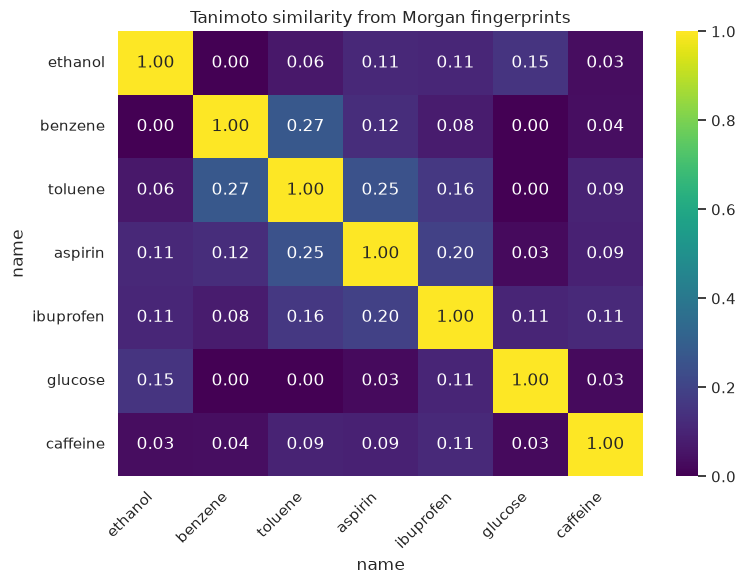

In [11]:
# 热图把相似性矩阵画出来；对角线一定是 1，因为每个分子和自己完全相同。
plt.figure(figsize=(8, 6))
sns.heatmap(sim_df, vmin=0, vmax=1, cmap="viridis", annot=True, fmt=".2f")
plt.title("Tanimoto similarity from Morgan fingerprints")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

可视化

('benzene', 'toluene') Tanimoto = 0.273


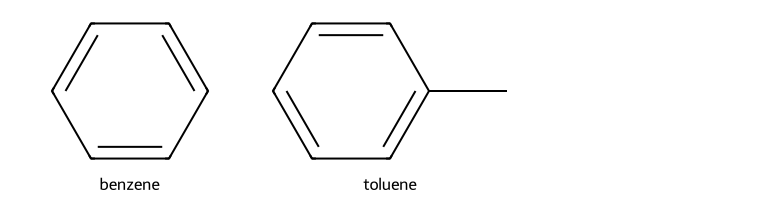

In [12]:
pair = ("benzene", "toluene")  # try ("ethanol", "glucose") or ("aspirin", "ibuprofen")
idx_a = examples.index[examples["name"] == pair[0]][0]
idx_b = examples.index[examples["name"] == pair[1]][0]

# 改 pair 可以快速检查“数值相似性”和你的化学直觉是否一致。
print(pair, "Tanimoto =", sim[idx_a, idx_b].round(3))
Draw.MolsToGridImage(
    [mol_from_smiles(examples.loc[idx_a, "smiles"]), mol_from_smiles(examples.loc[idx_b, "smiles"])],
    legends=list(pair),
    subImgSize=(260, 200),
)

## 观察问题

1. benzene 和 toluene 的相似度是否符合直觉？
2. descriptor 表中，哪个指标最容易和水溶性联系起来？
3. fingerprint 位本身不直观，为什么仍然有用？

### Hints

1. benzene 和 toluene 共享芳香环，Tanimoto 应该比较高；但 methyl 取代会引入额外片段，所以不会等于 1。
2. 可以先看 `MolLogP`、`TPSA`、`HBD`、`HBA`。水溶性常和极性、氢键能力、疏水性有关，但不会由单个 descriptor 完全决定。
3. fingerprint 的单个位不容易解释，但整组 bit 能高效表达大量局部结构片段，因此适合相似性搜索和机器学习输入。

# 不同similarity metric 的计算方式不同，结果也会不同。

### MACCS/MCS Similarity / Dice Similarity

In [18]:
from rdkit import Chem, DataStructs
from rdkit.Chem import MACCSkeys
from rdkit.Chem import rdFMCS

In [19]:
def maccs_similarity(smiles1: str, smiles2: str) -> float:
    """
    Compute MACCS fingerprint Tanimoto similarity between two molecules.

    MACCS keys are a 166-bit predefined structural key set capturing
    presence/absence of common chemical substructures.

    Parameters
    ----------
    smiles1 : str
        SMILES string of molecule 1
    smiles2 : str
        SMILES string of molecule 2

    Returns
    -------
    float
        Tanimoto similarity in [0, 1]

    Notes
    -----
    - MACCS is a fixed-key fingerprint (not hashed)
    - More interpretable than Morgan fingerprints
    - Often gives higher similarity for scaffold-preserving changes
    """

    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)

    fp1 = MACCSkeys.GenMACCSKeys(mol1)
    fp2 = MACCSkeys.GenMACCSKeys(mol2)

    return DataStructs.TanimotoSimilarity(fp1, fp2)

In [20]:
def mcs_similarity(smiles1: str, smiles2: str,
                   ring_matches_ring_only: bool = True,
                   complete_rings_only: bool = True,
                   match_valences: bool = True) -> float:
    """
    Compute Maximum Common Substructure (MCS)-based similarity.

    MCS similarity measures structural similarity based on the size of
    the largest shared subgraph between two molecules.

    Parameters
    ----------
    smiles1 : str
        SMILES string of molecule 1
    smiles2 : str
        SMILES string of molecule 2
    ring_matches_ring_only : bool
        Whether ring atoms must match ring atoms
    complete_rings_only : bool
        Whether only complete ring matches are allowed
    match_valences : bool
        Whether valence constraints are enforced

    Returns
    -------
    float
        MCS similarity defined as:
        |MCS| / max(|A|, |B|)

    Notes
    -----
    - More chemically intuitive than fingerprint similarity
    - Computationally expensive (NP-hard subgraph matching)
    - Sensitive to atom/bond typing rules
    """

    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)

    res = rdFMCS.FindMCS(
        [mol1, mol2],
        ringMatchesRingOnly=ring_matches_ring_only,
        completeRingsOnly=complete_rings_only,
        matchValences=match_valences
    )

    mcs_mol = Chem.MolFromSmarts(res.smartsString)
    mcs_size = mcs_mol.GetNumAtoms() if mcs_mol else 0

    size1 = mol1.GetNumAtoms()
    size2 = mol2.GetNumAtoms()

    return mcs_size / max(size1, size2)

In [21]:
def dice_similarity(smiles1: str, smiles2: str, radius: int = 2, nBits: int = 2048) -> float:
    """
    Compute Dice similarity between Morgan fingerprints.

    Dice coefficient is defined as:
        Dice = 2 * |A ∩ B| / (|A| + |B|)

    where A and B are binary fingerprint vectors.

    Parameters
    ----------
    smiles1 : str
        SMILES string of molecule 1
    smiles2 : str
        SMILES string of molecule 2
    radius : int
        Morgan fingerprint radius (default=2)
    nBits : int
        Length of fingerprint vector (default=2048)

    Returns
    -------
    float
        Dice similarity in [0, 1]

    Notes
    -----
    - More sensitive to small overlaps than Tanimoto
    - Common in image segmentation; less common in chemoinformatics
    - For sparse molecular fingerprints, often inflates similarity
    """

    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)

    fp1 = Chem.AllChem.GetMorganFingerprintAsBitVect(mol1, radius, nBits=nBits)
    fp2 = Chem.AllChem.GetMorganFingerprintAsBitVect(mol2, radius, nBits=nBits)

    return DataStructs.DiceSimilarity(fp1, fp2)

In [24]:
pair = ("benzene", "toluene")  # try ("ethanol", "glucose")

idx_a = examples.index[examples["name"] == pair[0]][0]
idx_b = examples.index[examples["name"] == pair[1]][0]

smiles_a = examples.loc[idx_a, "smiles"]
smiles_b = examples.loc[idx_b, "smiles"]

print(pair, "MACCS =", round(maccs_similarity(smiles_a, smiles_b), 3))
print(pair, "MCS   =", round(mcs_similarity(smiles_a, smiles_b), 3))
print(pair, "Dice (Morgan)  =", round(dice_similarity(smiles_a, smiles_b), 3))

('benzene', 'toluene') MACCS = 0.75
('benzene', 'toluene') MCS   = 0.857
('benzene', 'toluene') Dice (Morgan)  = 0.429


[22:31:36] DEPRECATION WARNING: please use MorganGenerator
[22:31:36] DEPRECATION WARNING: please use MorganGenerator


## 小结

descriptor 更容易解释，fingerprint 更适合捕捉局部结构。Tanimoto similarity 是基于 fingerprint 的相似性指标，不等于“真实化学相似性”的全部。